# HYDSYS: multirate cycles and component-condition labels

Explore 2,205 repeated 60-second cycles with 17 signals. Each sensor file is a
matrix: rows are cycles, columns are observations within a cycle. `profile.txt`
provides four condition targets and a stability flag for the same rows.

[UCI source](https://doi.org/10.24432/C5CW21) ·
[Dataset guide](../../pdmdata/datasets/hydsys/README.md)

Run `pdmdata.download("hydsys")` explicitly if needed. This notebook reads local
data and saves compact Matplotlib figures. Cycle IDs are **zero-based**.


In [1]:
from pathlib import Path
import sys
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pdmdata").is_dir())
sys.path.insert(0, str(ROOT))
import polars as pl
import matplotlib.pyplot as plt
from IPython.display import display
import pdmdata
from pdmdata.datasets.hydsys import inventory, profile, load_cycle
from pdmdata.datasets.hydsys.loader import SENSOR_INFO, TARGET_VALUES
from pdmdata.datasets.hydsys.viz import plot_cycle, plot_profile, plot_valve_comparison

sensors = inventory()
labels = profile()
print(f"Cycles: {labels.height:,}; channels: {sensors.height}; scalar measurements: {sensors['measurements'].sum():,}")
display(sensors.select("sensor", "sampling_hz", "unit", "cycles", "samples_per_cycle"))


Cycles: 2,205; channels: 17; scalar measurements: 96,314,400


sensor,sampling_hz,unit,cycles,samples_per_cycle
str,i64,str,i64,i64
"""PS1""",100,"""bar""",2205,6000
"""PS2""",100,"""bar""",2205,6000
"""PS3""",100,"""bar""",2205,6000
"""PS4""",100,"""bar""",2205,6000
"""PS5""",100,"""bar""",2205,6000
…,…,…,…,…
"""TS4""",1,"""deg C""",2205,60
"""VS1""",1,"""mm/s""",2205,60
"""CE""",1,"""%""",2205,60


## Condition labels and their distribution

Cooler values are 3/20/100%; valve values are 73/80/90/100%; pump leakage codes
are 0/1/2; accumulator pressures are 90/100/115/130 bar. These targets refer to
equipment condition throughout a cycle. They do not mark the switching phases
within that cycle. `stable_flag=0` means stable; 1 means steady state may not yet
have been reached. Stability is distinct from healthy component condition.


target,value,cycles
str,i64,i64
"""cooler_condition""",3,732
"""cooler_condition""",20,732
"""cooler_condition""",100,741
"""valve_condition""",73,360
"""valve_condition""",80,360
…,…,…
"""hydraulic_accumulator""",100,399
"""hydraulic_accumulator""",115,399
"""hydraulic_accumulator""",130,599


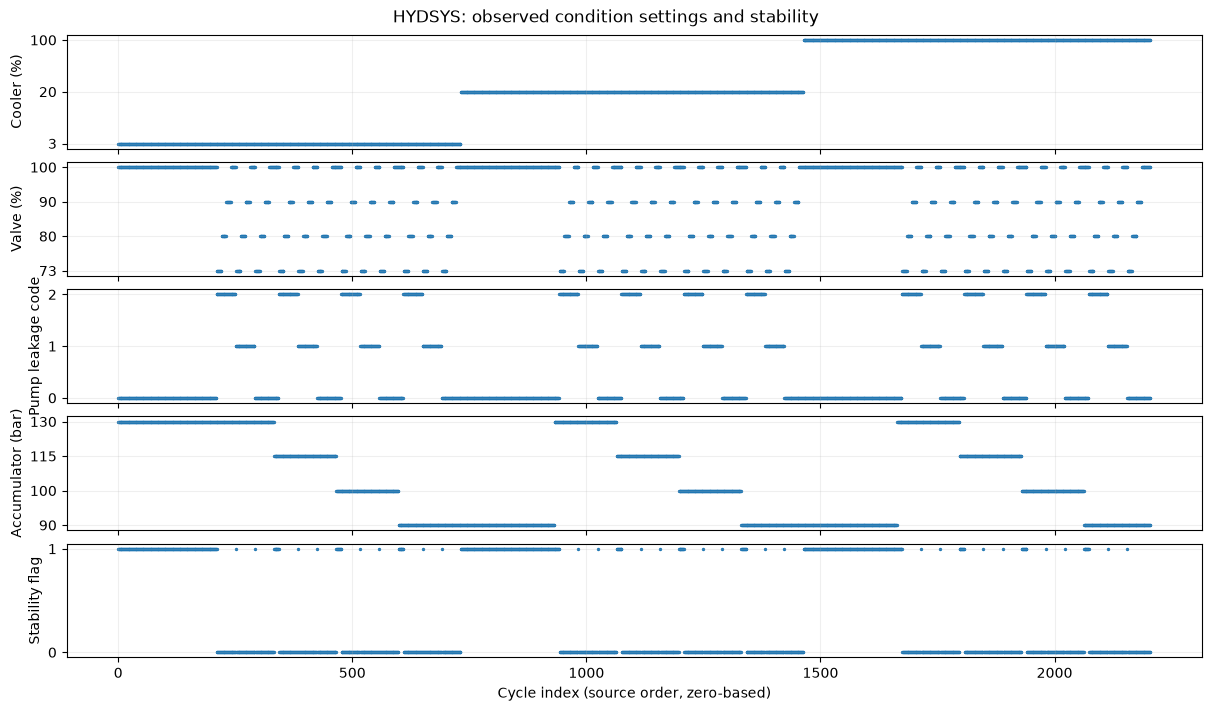

In [2]:
counts = []
for target in TARGET_VALUES:
    for row in labels.group_by(target).len().sort(target).iter_rows(named=True):
        counts.append({"target": target, "value": row[target], "cycles": row["len"]})
display(pl.DataFrame(counts))
condition_tracks = plot_profile(labels)
plt.show()


## Select a cycle and keep native sampling rates

The default selects the first stable cycle with nominal cooler, valve, pump,
and accumulator settings. It is an explicit reference selection, not a random
sample of the dataset. Change CYCLE to inspect any source row from 0 to 2204.

`load_cycle` returns separate frames keyed by rate: 100 Hz has seven signals,
10 Hz has two, and 1 Hz has eight. The time axis is `sample / rate`, with zero
assigned to the first observation; there are no recorded timestamps. We do not
interpolate lower-rate channels onto the faster grid.


cycle,cooler_condition,valve_condition,internal_pump_leakage,hydraulic_accumulator,stable_flag
u32,i16,i16,i16,i16,i16
1787,100,100,0,130,0


{100: (6000, 9), 10: (600, 4), 1: (60, 10)}


sensor,unique_values,standard_deviation
str,i64,f64
"""PS1""",637,13.959883
"""PS2""",587,47.171236
"""PS3""",235,0.947809
"""PS4""",107,0.032239
"""PS5""",94,0.021324
…,…,…
"""TS4""",15,0.043697
"""VS1""",45,0.02751
"""CE""",52,0.354878


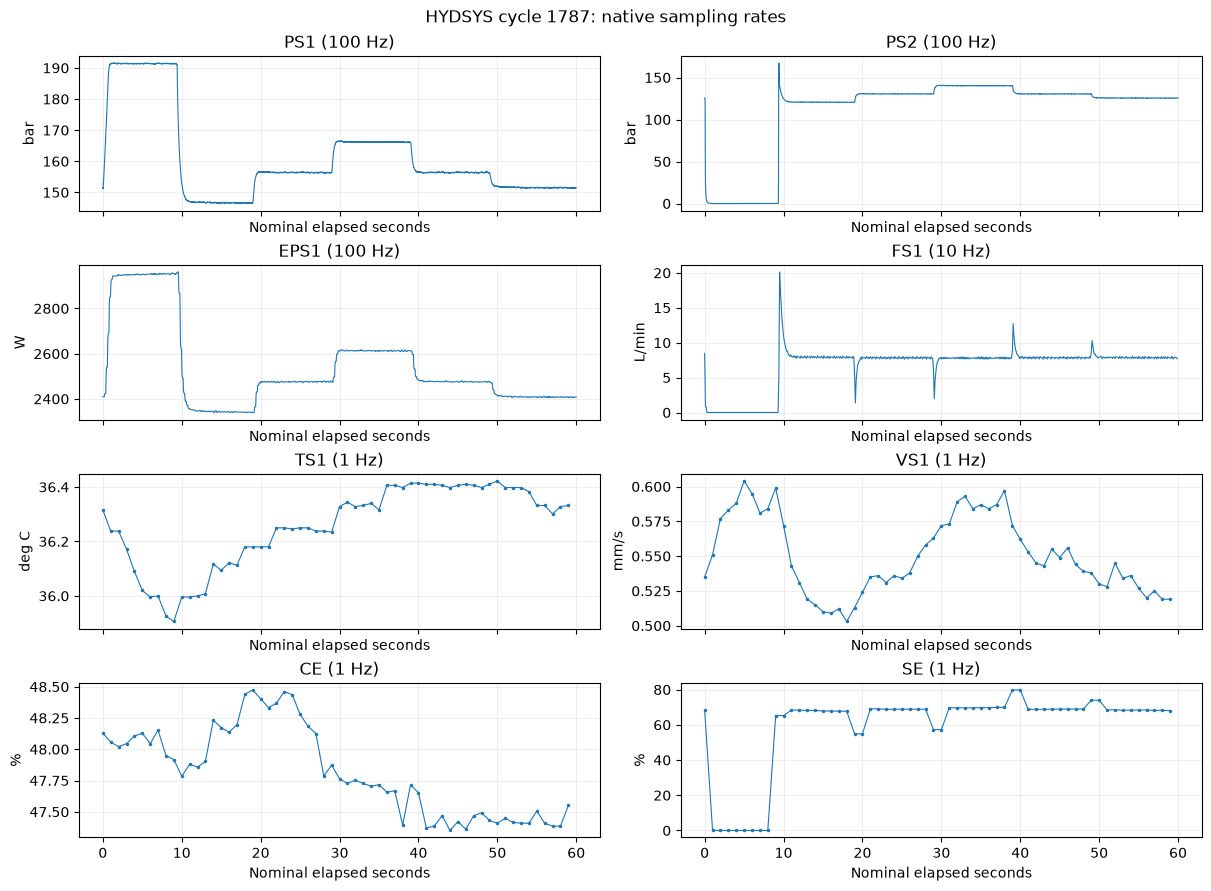

In [3]:
reference = labels.filter(
    (pl.col("cooler_condition") == 100) & (pl.col("valve_condition") == 100) &
    (pl.col("internal_pump_leakage") == 0) & (pl.col("hydraulic_accumulator") == 130) &
    (pl.col("stable_flag") == 0)
)
CYCLE = int(reference["cycle"][0])
groups = load_cycle(CYCLE)
display(labels.filter(pl.col("cycle") == CYCLE))
print({rate: frame.shape for rate, frame in groups.items()})
display(pl.DataFrame({"sensor": list(SENSOR_INFO),
    "unique_values": [groups[rate][sensor].n_unique() for sensor, (rate, _) in SENSOR_INFO.items()],
    "standard_deviation": [groups[rate][sensor].std() for sensor, (rate, _) in SENSOR_INFO.items()]}))
overview = plot_cycle(groups, cycle=CYCLE)
assets = ROOT / "pdmdata/datasets/hydsys/assets"
assets.mkdir(parents=True, exist_ok=True)
overview.savefig(assets / "waveforms.png", dpi=100)
plt.show()


## First two seconds of the seven 100 Hz signals

These six pressures and motor power share a native grid of 6,000 observations
per cycle. Selecting them gives seven dimensions, rather than 43,680 flattened
features. The latter counts time points across every channel in one cycle.


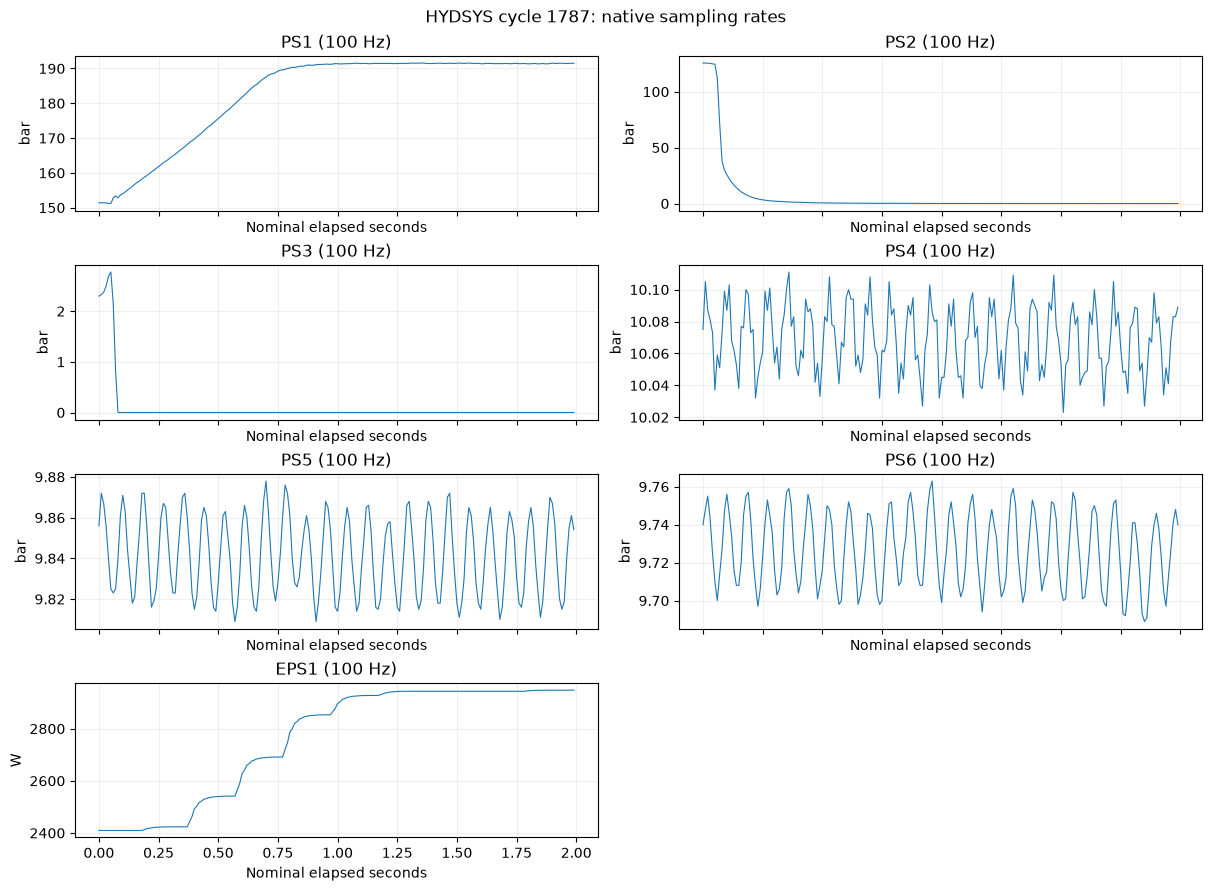

Native 100 Hz sensor matrix: (6000, 7)


In [4]:
FAST_SIGNALS = [sensor for sensor, (rate, _) in SENSOR_INFO.items() if rate == 100]
zoom = plot_cycle(groups, cycle=CYCLE, sensors=FAST_SIGNALS, start_s=0, stop_s=2)
plt.show()
# Sensor-only input; keep time indices and targets outside the model features.
X = groups[100].select(FAST_SIGNALS)
print("Native 100 Hz sensor matrix:", X.shape)


## Compare valve settings with the other labels held fixed

Select the first stable example for each valve condition, with cooler 100%,
pump leakage 0, and accumulator pressure 130 bar. This controls the recorded
condition labels; cycles are still different observations with possible drift
and other variation. Single examples do not quantify a causal effect or
classification performance.


valve_condition,cycle
i16,u32
73,1757
80,1767
90,1777
100,1787


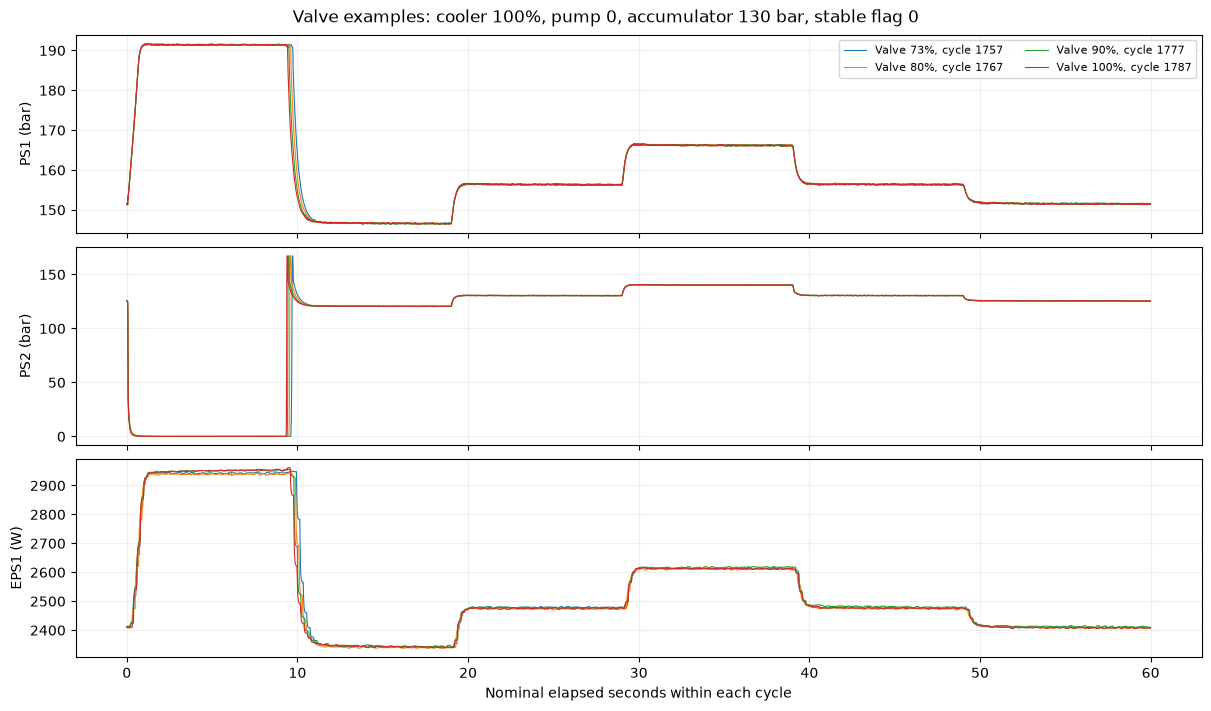

In [5]:
eligible = labels.filter(
    (pl.col("cooler_condition") == 100) & (pl.col("internal_pump_leakage") == 0) &
    (pl.col("hydraulic_accumulator") == 130) & (pl.col("stable_flag") == 0)
)
selected = eligible.group_by("valve_condition").agg(pl.col("cycle").min()).sort("valve_condition")
display(selected)
examples = [(valve, cycle, load_cycle(cycle, sensors=["PS1", "PS2", "EPS1"])[100])
            for valve, cycle in selected.iter_rows()]
valve_comparison = plot_valve_comparison(examples)
plt.show()


## Loading a matrix or a single sensor

`pdmdata.load("hydsys", sensor="PS1")` retains the matrix API: 2,205 cycle rows
by 6,000 sample columns. Adding `cycle=CYCLE` returns a long frame with sample,
time_s, and PS1. `profile()` gives one label row per zero-based cycle ID.

## Implications for dependency-based segmentation

- Start with the seven 100 Hz channels for an aligned, small multivariate input.
  Check constants and scale differences inside each training window.
- Lower-rate channels provide complementary processes at 10 Hz and 1 Hz. If
  combining rates, explicitly design aggregation/filtering and alignment rather
  than repeating slow samples and treating them as independent observations.
- The vibration channel VS1 is logged at 1 Hz; its name does not make it a raw
  high-frequency vibration waveform.
- Distinguish within-cycle load phases from between-cycle component conditions.
  The supplied targets support cycle-level evaluation, not supervised phase
  segmentation within the 60-second waveform.
- Repeated neighboring cycles share experimental conditions. Use blocked or
  grouped evaluation and avoid splitting windows from one cycle across folds.
- Treat stability as a quality criterion and report whether unstable cycles are
  excluded. A stable cycle can still contain a degraded component.
- Virtual CE/CP channels may encode derived relationships; do not interpret them
  as independent physical sensors when estimating sensor-dependency graphs.
- These controlled condition settings do not supply a run-to-failure trajectory
  or RUL annotations. Preserve separate cycle boundaries in exploratory analysis.

Source: Helwig, Pignanelli, and Schütze, *Condition monitoring of hydraulic
systems*, UCI Machine Learning Repository, DOI 10.24432/C5CW21.
The waveform preview selects eight channels from one cycle and adds labeled axes.
Source data and attribution: [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/).
